# Compare Two-Stage Q-Learning Performance

This notebook compares the performance of Two-Stage Q-Learning vs standard Q-Learning approaches by fetching metrics from Azure ML experiments using MLflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
import os
from pathlib import Path

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from tqdm import tqdm

# Enable inline plotting
%matplotlib inline

# Move to root folder for imports
os.chdir(Path.cwd().parent)
from src.azureml_utils import download_runs_artifacts
from experiments.utils import (
    fetch_metrics_for_runs,
    compute_mean_and_ci,
    plot_mean_mre,
    plot_mean_mre_multi_ka,
    load_run_state_errors,
    compute_per_state_series,
    plot_per_state_error,
)

# Load environment variables from .env file
load_dotenv()


False

In [ ]:
# Connect to Azure ML Workspace using SDK v2 and setup MLflow
# The workspace will be loaded from config.json file if available, or you can specify parameters
try:
    # Using DefaultAzureCredential for authentication
    credential = DefaultAzureCredential()
    credential.get_token("https://management.azure.com/.default")
    # Create ML Client from config.json
    ml_client = MLClient.from_config(credential=credential)
    print(f"Connected to workspace: {ml_client.workspace_name}")
    print(f"Subscription: {ml_client.subscription_id}")
    print(f"Resource group: {ml_client.resource_group_name}")

except Exception as e:
    print(f"Error connecting to workspace: {e}")
    raise

# Set up MLflow tracking URI for Azure ML
tracking_uri = ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri
mlflow.set_tracking_uri(tracking_uri)
print(f"✓ MLflow tracking URI set successfully to {mlflow.get_tracking_uri()}")

client = mlflow.tracking.MlflowClient()

Found the config file in: ./config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


Connected to workspace: mlw-research-pro-003
Subscription: 706e41e6-9c7a-47c4-b231-c6e8897cfb63
Resource group: rg-research-pro-003
✓ MLflow tracking URI set successfully to azureml://westeurope.api.azureml.ms/mlflow/v2.0/subscriptions/706e41e6-9c7a-47c4-b231-c6e8897cfb63/resourceGroups/rg-research-pro-003/providers/Microsoft.MachineLearningServices/workspaces/mlw-research-pro-003


## Compare Q-Learning and Smart Q-Learning (N=5)

In [5]:
experiment = mlflow.get_experiment_by_name("SIRS-Q-Learning")
runs_size_5 = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_5' OR tags.run_group = 'smart_5'",
    order_by=["start_time DESC"],
)
runs_size_5.shape

(10, 56)

In [6]:
download_runs_artifacts(
    run_names=runs_size_5["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)

Runs:  10%|█         | 1/10 [00:00<00:06,  1.40run/s]

  cool_office_7b4ty60dp7: 0 downloaded, 1010 skipped


Runs:  20%|██        | 2/10 [00:01<00:04,  1.79run/s]

  mango_bridge_jr34gmn1v6: 0 downloaded, 1010 skipped


Runs:  30%|███       | 3/10 [00:01<00:03,  2.07run/s]

...

Runs:  90%|█████████ | 9/10 [00:05<00:00,  1.91run/s]

  shy_quince_p8nb8fkjx2: 0 downloaded, 1010 skipped


Runs: 100%|██████████| 10/10 [00:05<00:00,  1.69run/s]

  olden_wheel_4q4yqs86s3: 0 downloaded, 1010 skipped

Done — 10/10 runs succeeded (0 files downloaded, 10100 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts


{'cool_office_7b4ty60dp7': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/cool_office_7b4ty60dp7'),
 'mango_bridge_jr34gmn1v6': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/mango_bridge_jr34gmn1v6'),
 'mango_guava_l5qg9clfqg': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/mango_guava_l5qg9clfqg'),
 'placid_toe_l4xyh1zhvg': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/placid_toe_l4xyh1zhvg'),
 'clever_parang_jn9r5r3hwh': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/clever_parang_jn9r5r3hwh'),
 'loving_lettuce_kvj1tstrs4': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/loving_lettuce_kvj1tstrs4'),
 'happy_frog_q2wg4ndrb3': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/happy_frog_q2wg4ndrb3'),
 'orange_grass_4kjyc3c5ss': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/art

In [7]:
metrics_size_5 = fetch_metrics_for_runs(client, runs_size_5, "log_mean_relative_error")

100%|██████████| 10/10 [00:27<00:00,  2.75s/it]


In [9]:
complete_size_5 = metrics_size_5[metrics_size_5["tags.learn_mode"] == "complete"]
two_stage_size_5 = metrics_size_5[metrics_size_5["tags.learn_mode"] == "two_stages"]

print(
    f"Size=5 — Q-learning: {complete_size_5['run_id'].nunique()} runs | Smart Q-learning: {two_stage_size_5['run_id'].nunique()} runs")

Size=5 — Q-learning: 5 runs | Smart Q-learning: 5 runs


Size=5 — Q-learning: 5 runs | Smart Q-learning: 5 runs


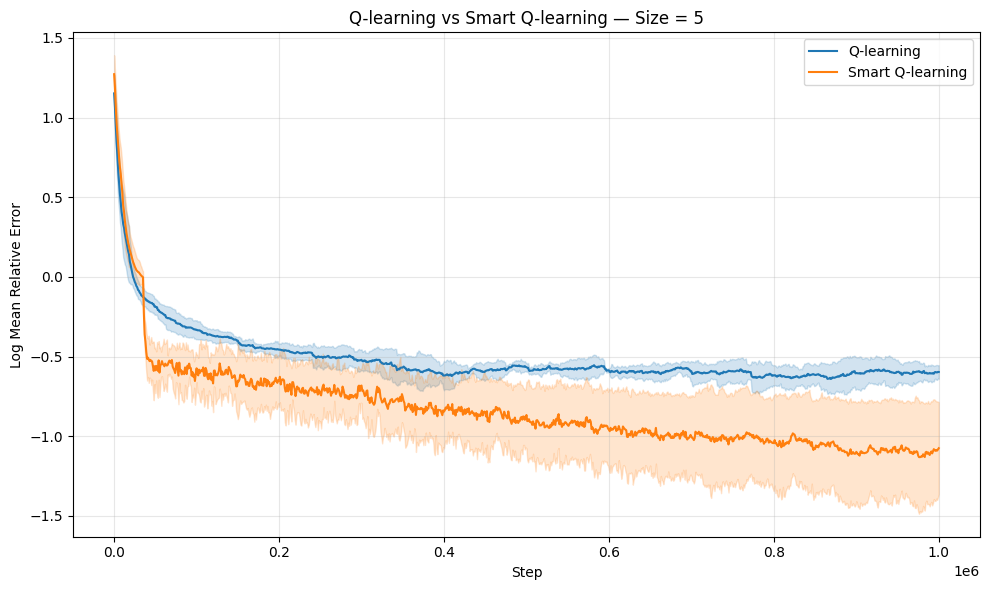

In [10]:
print(f"Size=5 — Q-learning: {complete_size_5['run_id'].nunique()} runs | Smart Q-learning: {two_stage_size_5['run_id'].nunique()} runs")
plot_mean_mre(complete_size_5, two_stage_size_5, "Q-learning vs Smart Q-learning — Size = 5")
plt.show()


In [12]:
# Load per-state errors for all runs in runs_size_5 that have downloaded artifacts
per_state_errors_5 = {}
for _, row in tqdm(runs_size_5.iterrows(), total=len(runs_size_5)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        per_state_errors_5[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in per_state_errors_5.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in per_state_errors_5.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(per_state_errors_5)} runs with local artifacts "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)


  0%|          | 0/10 [00:00<?, ?it/s]

/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:169: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 10/10 [00:22<00:00,  2.21s/it]

Loaded 10 runs with local artifacts (5 complete, 5 two_stages)


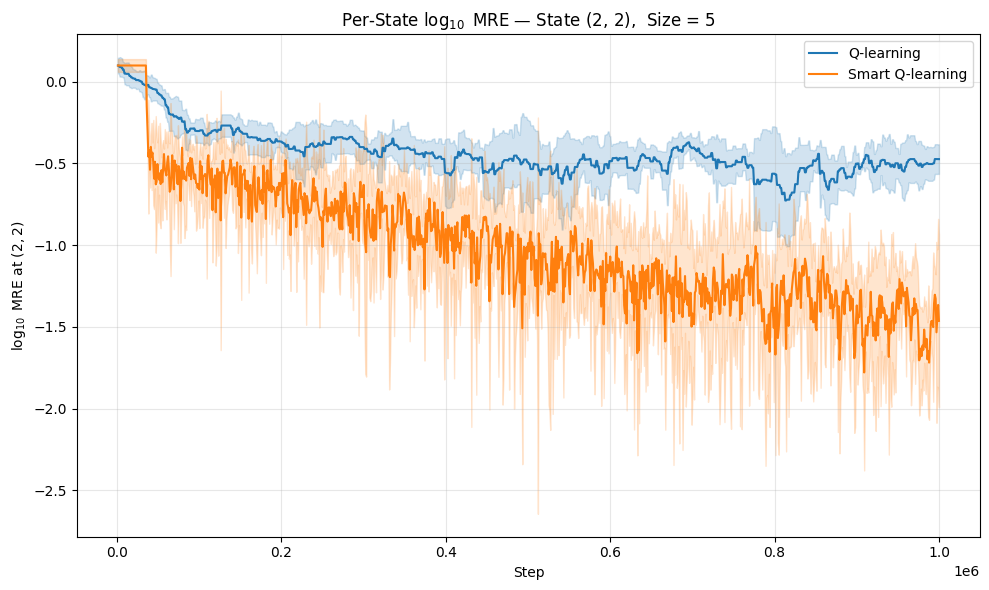

In [17]:
# ── Choose any valid state (m_s + m_i <= size) and run this cell ──
m_s, m_i = 2,2
plot_per_state_error(per_state_errors_5, m_s, m_i, size_label="Size = 5")
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=5, No reinfection)

In [37]:
runs_size_5_no_reinf = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_5_noreinf' or tags.run_group = 'smart_5_noreinf'",
    order_by=["start_time DESC"],
)
runs_size_5_no_reinf.shape

(15, 56)

In [41]:
runs_size_5_no_reinf_55000 = runs_size_5_no_reinf[
    (runs_size_5_no_reinf["params.first_stage_steps"] == "55000")
    | (runs_size_5_no_reinf["tags.learn_mode"] == "complete")
]
metrics_size_5_no_reinf_55000 = fetch_metrics_for_runs(client, runs_size_5_no_reinf_55000)
complete_size_5_no_reinf_55000 = metrics_size_5_no_reinf_55000[metrics_size_5_no_reinf_55000["tags.learn_mode"] == "complete"]
two_stage_size_5_no_reinf_55000 = metrics_size_5_no_reinf_55000[metrics_size_5_no_reinf_55000["tags.learn_mode"] == "two_stages"]


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:18<00:00,  1.85s/it]


Size=5 — Q-learning: 5 runs | Smart Q-learning: 5 runs


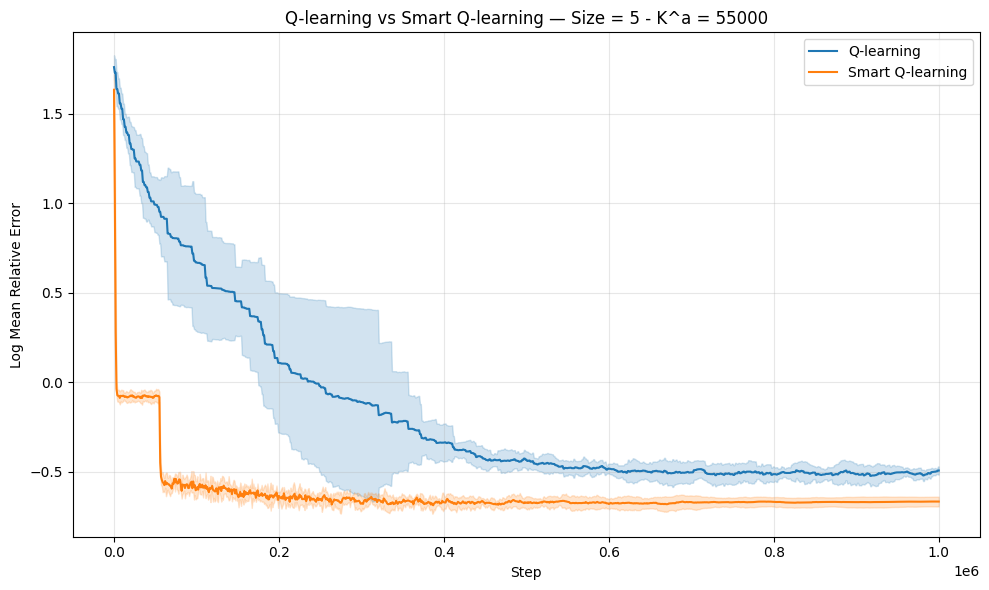

In [42]:
print(f"Size=5 — Q-learning: {complete_size_5_no_reinf_55000['run_id'].nunique()} runs | Smart Q-learning: {two_stage_size_5_no_reinf_55000['run_id'].nunique()} runs")
plot_mean_mre(complete_size_5_no_reinf_55000, two_stage_size_5_no_reinf_55000, "Q-learning vs Smart Q-learning — Size = 5 - K^a = 55000")
plt.show()

In [45]:
download_runs_artifacts(
    run_names=runs_size_5_no_reinf_55000["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)

Runs:  10%|█         | 1/10 [00:00<00:07,  1.25run/s]

  elated_calypso_rzzrlmpjkj: 0 downloaded, 1010 skipped


Runs:  20%|██        | 2/10 [00:01<00:04,  1.71run/s]

  joyful_tail_5474w5r2mz: 0 downloaded, 1010 skipped


Runs:  30%|███       | 3/10 [00:01<00:03,  2.07run/s]

...

Runs:  90%|█████████ | 9/10 [00:03<00:00,  2.56run/s]

  boring_pen_wsd599qmk2: 0 downloaded, 1010 skipped


Runs: 100%|██████████| 10/10 [00:04<00:00,  2.29run/s]

  nifty_shoe_08k24fl6j6: 0 downloaded, 1010 skipped

Done — 10/10 runs succeeded (0 files downloaded, 10100 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/artifacts


{'elated_calypso_rzzrlmpjkj': PosixPath('/Users/ccarballo/Projects/Research/artifacts/elated_calypso_rzzrlmpjkj'),
 'joyful_tail_5474w5r2mz': PosixPath('/Users/ccarballo/Projects/Research/artifacts/joyful_tail_5474w5r2mz'),
 'eager_lychee_jp04xrt8zj': PosixPath('/Users/ccarballo/Projects/Research/artifacts/eager_lychee_jp04xrt8zj'),
 'honest_comb_vj25nvx8yc': PosixPath('/Users/ccarballo/Projects/Research/artifacts/honest_comb_vj25nvx8yc'),
 'nifty_music_2qfv2fbnpw': PosixPath('/Users/ccarballo/Projects/Research/artifacts/nifty_music_2qfv2fbnpw'),
 'mighty_tail_qn6l3bfsr9': PosixPath('/Users/ccarballo/Projects/Research/artifacts/mighty_tail_qn6l3bfsr9'),
 'heroic_king_hbvl95lxtc': PosixPath('/Users/ccarballo/Projects/Research/artifacts/heroic_king_hbvl95lxtc'),
 'kind_peach_3t7bf4ddms': PosixPath('/Users/ccarballo/Projects/Research/artifacts/kind_peach_3t7bf4ddms'),
 'boring_pen_wsd599qmk2': PosixPath('/Users/ccarballo/Projects/Research/artifacts/boring_pen_wsd599qmk2'),
 'nifty_shoe_08

In [44]:
states_errors_5_noreinf = {}
for _, row in tqdm(runs_size_5_no_reinf.iterrows(), total=len(runs_size_5_no_reinf)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_5_noreinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete_5_no_reinf = sum(1 for v in states_errors_5_noreinf.values() if v["learn_mode"] == "complete")
n_two_stages_5_no_reinf = sum(1 for v in states_errors_5_noreinf.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(states_errors_5_noreinf)} runs with local artifacts "
    f"({n_complete_5_no_reinf} complete, {n_two_stages_5_no_reinf} two_stages)"
)

  0%|          | 0/15 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:169: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 15/15 [00:03<00:00,  3.88it/s]

Loaded 15 runs with local artifacts (5 complete, 10 two_stages)


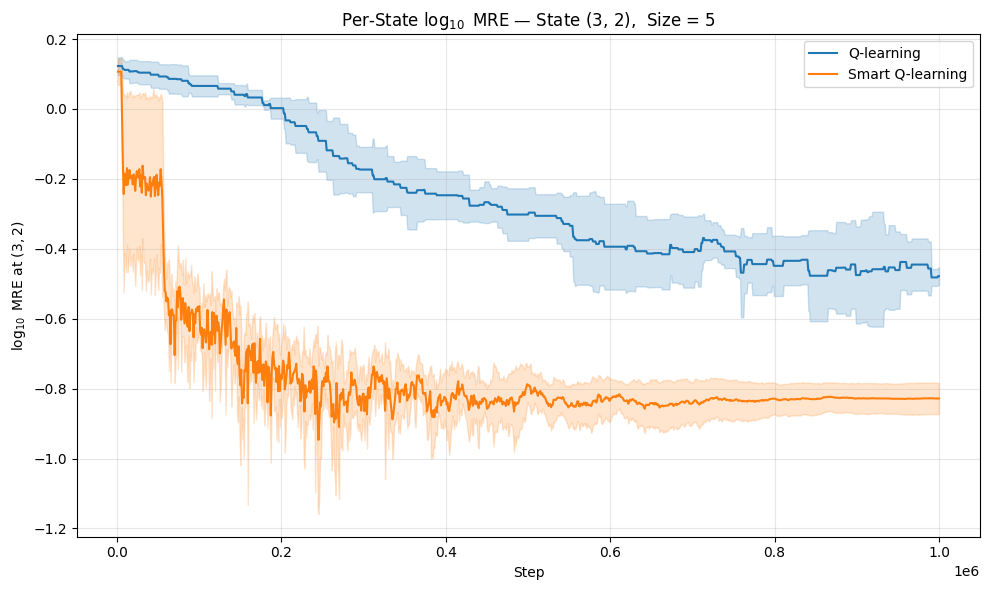

In [46]:
# ── Choose any valid state (m_s + m_i <= size) and run this cell ──
m_s, m_i = 3,2
plot_per_state_error(states_errors_5_noreinf, m_s, m_i, size_label="Size = 5")
plt.show()


100%|██████████| 10/10 [00:14<00:00,  1.40s/it]

Size=5 — Q-learning: 5 runs | Smart Q-learning: 5 runs


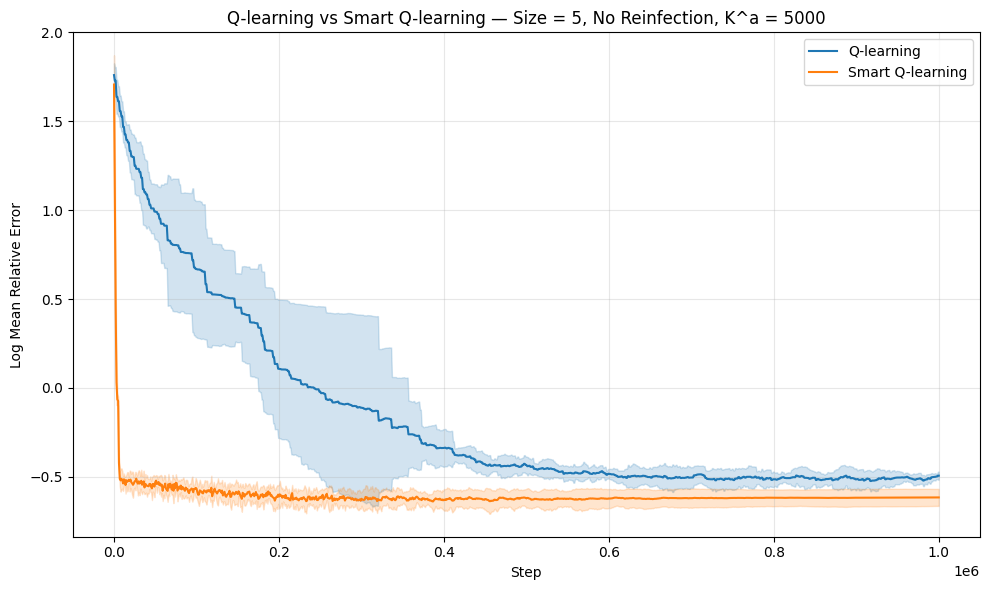

In [47]:
runs_size_5_no_reinf_5000 = runs_size_5_no_reinf[
    (runs_size_5_no_reinf["params.first_stage_steps"] == "5000")
    | (runs_size_5_no_reinf["tags.learn_mode"] == "complete")
]
metrics_size_5_no_reinf_5000 = fetch_metrics_for_runs(client, runs_size_5_no_reinf_5000)
complete_size_5_no_reinf_5000 = metrics_size_5_no_reinf_5000[metrics_size_5_no_reinf_5000["tags.learn_mode"] == "complete"]
two_stage_size_5_no_reinf_5000 = metrics_size_5_no_reinf_5000[metrics_size_5_no_reinf_5000["tags.learn_mode"] == "two_stages"]
print(f"Size=5 — Q-learning: {complete_size_5_no_reinf_5000['run_id'].nunique()} runs | Smart Q-learning: {two_stage_size_5_no_reinf_5000['run_id'].nunique()} runs")
plot_mean_mre(complete_size_5_no_reinf_5000, two_stage_size_5_no_reinf_5000, "Q-learning vs Smart Q-learning — Size = 5, No Reinfection, K^a = 5000")
plt.show()


In [48]:
download_runs_artifacts(
    run_names=runs_size_5_no_reinf_5000["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)


Runs:  10%|█         | 1/10 [00:01<00:09,  1.11s/run]

  gray_lemon_pv5kxyj906: 0 downloaded, 2012 skipped


Runs:  20%|██        | 2/10 [00:02<00:08,  1.02s/run]

  nice_leaf_vh1w3lkhzn: 0 downloaded, 2012 skipped


Runs:  30%|███       | 3/10 [00:02<00:06,  1.14run/s]

...

Runs:  90%|█████████ | 9/10 [00:07<00:00,  1.58run/s]

  boring_pen_wsd599qmk2: 0 downloaded, 1010 skipped


Runs: 100%|██████████| 10/10 [00:07<00:00,  1.28run/s]

  nifty_shoe_08k24fl6j6: 0 downloaded, 1010 skipped

Done — 10/10 runs succeeded (0 files downloaded, 15110 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/artifacts


{'gray_lemon_pv5kxyj906': PosixPath('/Users/ccarballo/Projects/Research/artifacts/gray_lemon_pv5kxyj906'),
 'nice_leaf_vh1w3lkhzn': PosixPath('/Users/ccarballo/Projects/Research/artifacts/nice_leaf_vh1w3lkhzn'),
 'busy_chin_wfgjp7jfc7': PosixPath('/Users/ccarballo/Projects/Research/artifacts/busy_chin_wfgjp7jfc7'),
 'bubbly_ice_97h7svbzlr': PosixPath('/Users/ccarballo/Projects/Research/artifacts/bubbly_ice_97h7svbzlr'),
 'gray_gas_9xh78j36q8': PosixPath('/Users/ccarballo/Projects/Research/artifacts/gray_gas_9xh78j36q8'),
 'mighty_tail_qn6l3bfsr9': PosixPath('/Users/ccarballo/Projects/Research/artifacts/mighty_tail_qn6l3bfsr9'),
 'heroic_king_hbvl95lxtc': PosixPath('/Users/ccarballo/Projects/Research/artifacts/heroic_king_hbvl95lxtc'),
 'kind_peach_3t7bf4ddms': PosixPath('/Users/ccarballo/Projects/Research/artifacts/kind_peach_3t7bf4ddms'),
 'boring_pen_wsd599qmk2': PosixPath('/Users/ccarballo/Projects/Research/artifacts/boring_pen_wsd599qmk2'),
 'nifty_shoe_08k24fl6j6': PosixPath('/Use

In [49]:
states_errors_5_noreinf_5000 = {}
for _, row in tqdm(runs_size_5_no_reinf_5000.iterrows(), total=len(runs_size_5_no_reinf_5000)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_5_noreinf_5000[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_5_noreinf_5000.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_5_noreinf_5000.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(states_errors_5_noreinf_5000)} runs with local artifacts "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)


  0%|          | 0/10 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:169: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 10/10 [00:02<00:00,  3.73it/s]

Loaded 10 runs with local artifacts (5 complete, 5 two_stages)


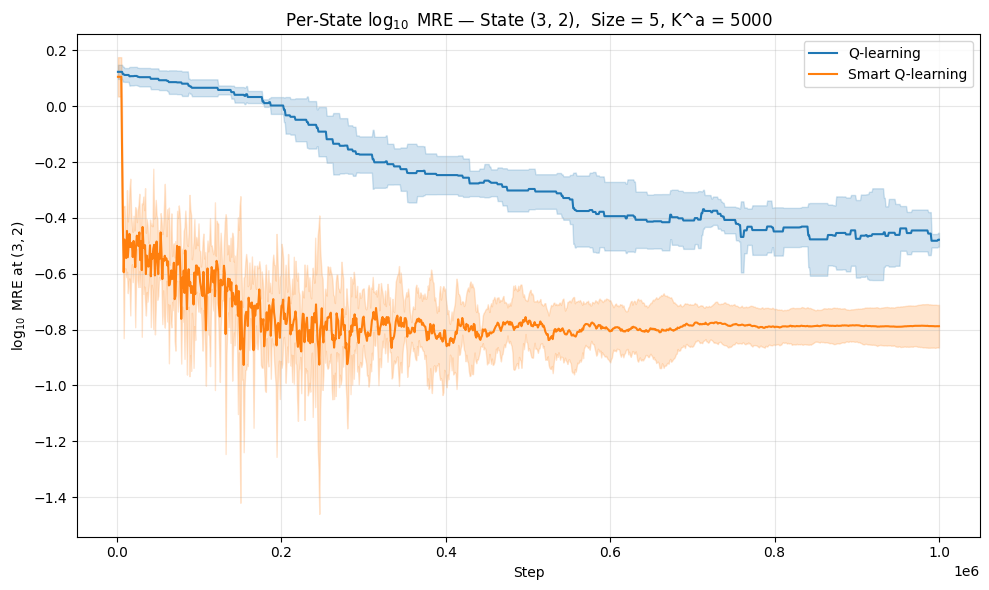

In [54]:
# ── Choose any valid state (m_s + m_i <= size) and run this cell ──
m_s, m_i = 3, 2
plot_per_state_error(states_errors_5_noreinf_5000, m_s, m_i, size_label="Size = 5, K^a = 5000")
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=10)

In [55]:
runs_size_10 = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_10' OR tags.run_group = 'smart_10'",
    order_by=["start_time DESC"],
)

# Split by learn mode and K^a
metrics_size_10 = fetch_metrics_for_runs(client, runs_size_10)
complete_size_10 = metrics_size_10[metrics_size_10["tags.learn_mode"] == "complete"]

two_stage_size_10_series = []
for ka in ["105000", "150000", "300000"]:
    run_ids = runs_size_10[
        (runs_size_10["tags.learn_mode"] == "two_stages")
        & (runs_size_10["params.first_stage_steps"] == ka)
    ]["run_id"]
    df = metrics_size_10[metrics_size_10["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_10_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=10 — Q-learning: {complete_size_10['run_id'].nunique()} runs")
for label, df in two_stage_size_10_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


100%|██████████| 20/20 [00:31<00:00,  1.56s/it]

Size=10 — Q-learning: 5 runs
  Smart Q-learning (K^a = 105,000): 5 runs
  Smart Q-learning (K^a = 150,000): 5 runs
  Smart Q-learning (K^a = 300,000): 5 runs


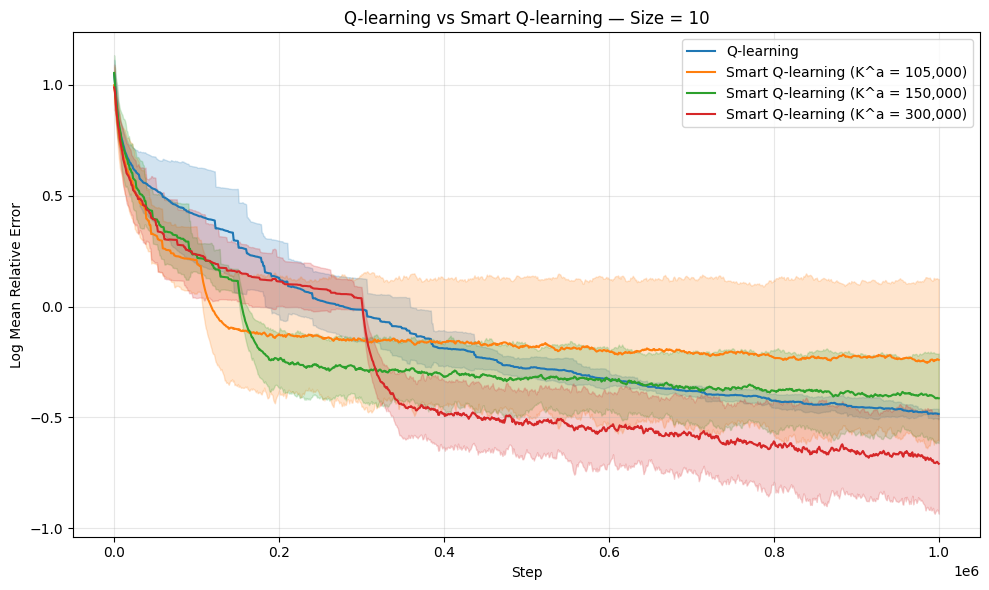

In [56]:
plot_mean_mre_multi_ka(
    complete_size_10,
    two_stage_size_10_series,
    "Q-learning vs Smart Q-learning — Size = 10",
)
plt.show()
